Tools for RAG Agents with Langgraph

In [16]:
import os
from langchain_core.tools import tool,Tool
from langchain.agents import create_agent
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import WebBaseLoader,TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from typing import Annotated,Sequence,TypedDict
from pydantic import BaseModel
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun

In [7]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016E9BCEEA80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016E9BD03350>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Generic function for retriever tool

In [26]:
def make_retriever_tool_from_text(file):
    docs = TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks,HuggingFaceEmbeddings(model="all-MiniLM-L6-v2"))
    retriever = vs.as_retriever()

    @tool
    def tool_fnc(query: str) -> str:
        "Search Internal Tech documents for proprietary architecture and methods"
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)
    
    return tool_fnc


wiki_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=1,
        doc_content_chars_max=1000
    )
)

two retriever for two docs

In [27]:
internal_tool_1 = make_retriever_tool_from_text("internal_doc.txt")
internal_tool_1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

StructuredTool(name='tool_fnc', description='Search Internal Tech documents for proprietary architecture and methods', args_schema=<class 'langchain_core.utils.pydantic.tool_fnc'>, func=<function make_retriever_tool_from_text.<locals>.tool_fnc at 0x0000016EA00105E0>)

In [28]:
internal_tool_2 = make_retriever_tool_from_text("research_notes.txt")
internal_tool_2

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

StructuredTool(name='tool_fnc', description='Search Internal Tech documents for proprietary architecture and methods', args_schema=<class 'langchain_core.utils.pydantic.tool_fnc'>, func=<function make_retriever_tool_from_text.<locals>.tool_fnc at 0x0000016EC2361C60>)

In [29]:
tools = [internal_tool_1,internal_tool_2,wiki_tool]

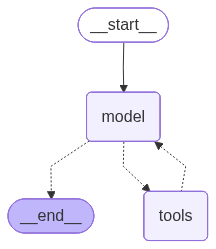

In [30]:
react_node = create_agent(model=llm,tools=tools)
react_node

In [31]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

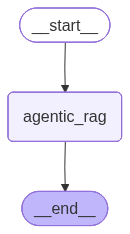

In [32]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag",react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag",END)
graph=builder.compile()
graph

In [33]:
query = "What do our internal research notes say about transformer variants and what does Wikipedia suggest recently"
state = {"messages":[HumanMessage(content=query)]}
result = graph.invoke(state)
print(f"Answer: {result['messages'][-1].content}")

Answer: Based on the internal research notes, it appears that the team is working on a project called "Project Falcon" which involves developing a transformer variant for various applications such as logistics, retail, and manufacturing. The notes mention that the prototype has achieved an accuracy of 91.7% and that the team is working on adding offline mode and reducing GPU memory consumption.

The Wikipedia entry suggests that the latest transformer variant, GPT-5.4, has been released by OpenAI and offers improved performance and capabilities compared to previous versions. The model is available in different variants, including GPT-5.4 mini and GPT-5.4 nano, which are more expensive but offer better performance. GPT-5.4 has built-in computer use capabilities and improved deep research capabilities, making it a powerful tool for various applications.
